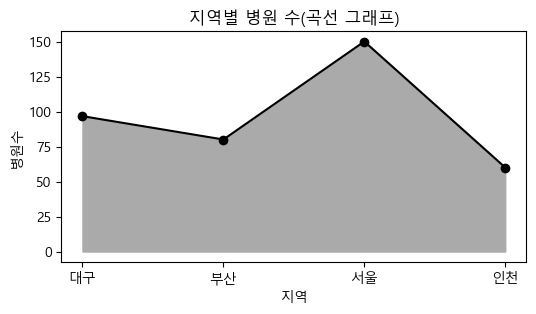

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
# 숫자 계산 쉽게하는 라이브러리
import numpy as np
# 데이터 사이를 부드럽게 연결해주는 함수
from scipy.interpolate import make_interp_spline

# 데이터 생성하기
df1 = pd.DataFrame({
    "지역" : ["서울", "부산", "대구"],
    "총인구" : [1000000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역" : ["서울", "부산", "인천"],
    "병원수" : [150, 80, 60]
})

# 데이터 전처리를 위해 merge(병합)을 진행한다.
# outer로 병합하면 df1과 df2가 합집합이 된다.
merged = pd.merge(df1, df2, on = "지역", how = "outer")
merged

# 결측치 처리를 진행한다.
# 결측치는 병원수와 총인구의 평균으로 정의한다.
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())
merged

# -------------------------------------
# 반드시 한극 깨짐 현상 코드 삽입
# -------------------------------------

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(6,3))

plt.plot(merged['지역'], merged['병원수'], marker = 'o', color = 'black')

# 꺾은선 영역 그래프
# fill_between(x,y) => x축 기준으로 선아래를 채워라
# plt.fill_between(x,y,alpha = 0.3) => 투명도 0.1 : 거의 안보임  / 03. : 적당 / 1 ~ : 아주 진함
plt.fill_between(merged['지역'], merged['병원수'], alpha = 1, color = '#aaa')

# x 축을 숫자로 변환
x = np.arange(len(merged['지역']))
y = merged['병원수']
smooth = np.linspace(x.min(), x.max(), 300)
smooth02 = make_interp_spline(x,y)(smooth)
# plt.plot(smooth, smooth02)

plt.title('지역별 병원 수(곡선 그래프)')
plt.xlabel('지역')
plt.ylabel('병원수')

plt.show()